# Exemplo 07 - Caixeiro Viajante (TSP) com DEAP

---

## O Problema

Um vendedor precisa visitar **8 cidades brasileiras** e voltar ao ponto de partida. Ele quer encontrar a **rota mais curta** que passe por todas as cidades exatamente uma vez.

**TSP (Traveling Salesperson Problem)**

## Onde isso aparece na vida real?

| Area | Exemplo |
|:---|:---|
| Logistica | Rotas de entrega (Sedex, iFood, Uber) |
| Industria | Caminho de furacao em placas de circuito |
| Robotica | Trajetoria de robos em armazens |
| Bioinformatica | Sequenciamento de DNA |

## Por que este exemplo e especial?

Nos exemplos anteriores usamos cromossomos **binarios** `[0, 1, 0, 1]`.  
Aqui usamos cromossomos de **permutacao** `[3, 1, 4, 0, 2, ...]`.  
Cada gene e uma **cidade**, e a **ordem** importa!

### Problema com crossover normal:

```
Pai 1:  [0, 1, 2, 3 | 4, 5, 6, 7]
Pai 2:  [3, 5, 7, 1 | 0, 2, 4, 6]

Crossover de 1 ponto (corte na posicao 4):
Filho:  [0, 1, 2, 3 | 0, 2, 4, 6]  <- ERRO!
          ^              ^
        Cidade 0 REPETIDA! Cidades 5 e 7 PERDIDAS!
```

**Solucao:** usar **Crossover Ordenado (OX)**, que garante que cada cidade aparece exatamente uma vez.

In [ ]:
%pip install deap -q

In [1]:
import random
import math
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

---
## Passo 1: Definir as cidades

In [2]:
cidades = {
    0: {"nome": "Sao Paulo",      "x": 350, "y": 600},
    1: {"nome": "Rio de Janeiro",  "x": 450, "y": 580},
    2: {"nome": "Belo Horizonte",  "x": 400, "y": 500},
    3: {"nome": "Brasilia",        "x": 300, "y": 400},
    4: {"nome": "Salvador",        "x": 500, "y": 350},
    5: {"nome": "Curitiba",        "x": 320, "y": 650},
    6: {"nome": "Recife",          "x": 550, "y": 250},
    7: {"nome": "Fortaleza",       "x": 500, "y": 150},
}

NUM_CIDADES = len(cidades)

print("Cidades a visitar:")
for i, cidade in cidades.items():
    print("  ", i, "-", cidade["nome"], "\t(", cidade["x"], ",", cidade["y"], ")")

print("\nTotal de cidades:", NUM_CIDADES)
print("Total de rotas possiveis:", math.factorial(NUM_CIDADES), "(", NUM_CIDADES, "!)")

Cidades a visitar:
   0 - Sao Paulo 	( 350 , 600 )
   1 - Rio de Janeiro 	( 450 , 580 )
   2 - Belo Horizonte 	( 400 , 500 )
   3 - Brasilia 	( 300 , 400 )
   4 - Salvador 	( 500 , 350 )
   5 - Curitiba 	( 320 , 650 )
   6 - Recife 	( 550 , 250 )
   7 - Fortaleza 	( 500 , 150 )

Total de cidades: 8
Total de rotas possiveis: 40320 ( 8 !)


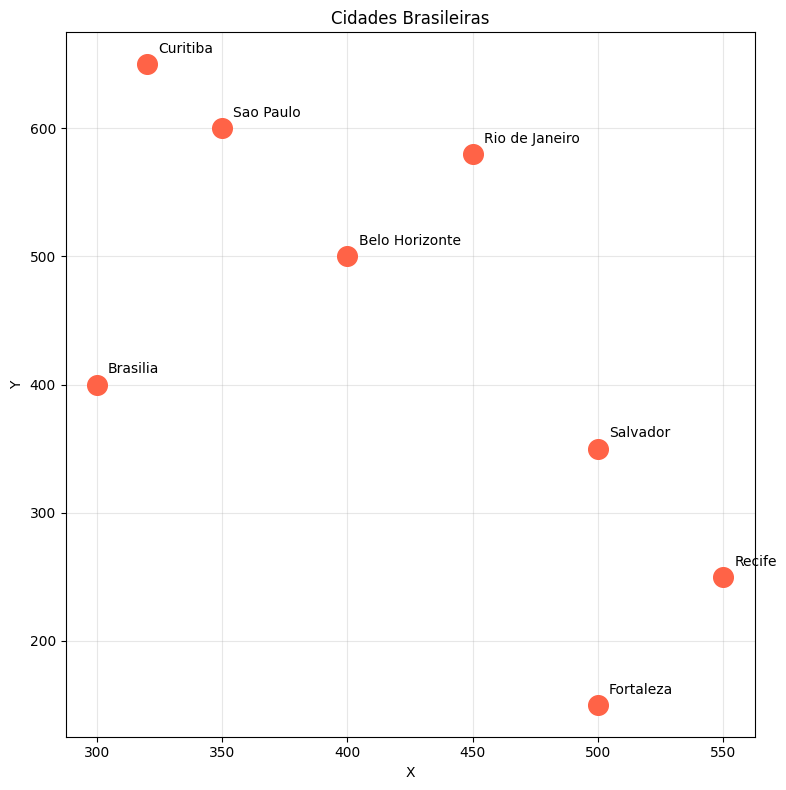

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

for cidade in cidades.values():
    ax.scatter(cidade["x"], cidade["y"], s=200, c="tomato", zorder=3)
    ax.annotate(cidade["nome"], (cidade["x"], cidade["y"]),
                textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.set_title("Cidades Brasileiras")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Com apenas 8 cidades ja temos **40.320 rotas** possiveis!  
Com 20 cidades seriam **2.4 quintilhoes**. Impossivel por forca bruta.

---
## Passo 2: Funcoes de distancia

In [4]:
def distancia(cidade_a, cidade_b):
    """Distancia euclidiana entre duas cidades."""
    dx = cidades[cidade_a]["x"] - cidades[cidade_b]["x"]
    dy = cidades[cidade_a]["y"] - cidades[cidade_b]["y"]
    return math.sqrt(dx**2 + dy**2)


def distancia_total(rota):
    """Distancia total de uma rota (ida + volta ao inicio)."""
    total = 0
    for i in range(len(rota) - 1):
        total += distancia(rota[i], rota[i+1])
    total += distancia(rota[-1], rota[0])
    return total


# Testar com rota natural
rota_natural = list(range(NUM_CIDADES))
print("Rota natural:", rota_natural)
print("Distancia:", round(distancia_total(rota_natural), 1))

Rota natural: [0, 1, 2, 3, 4, 5, 6, 7]
Distancia: 1941.3


---
## Passo 3: Visualizar as cidades no mapa

Vamos ver as cidades e a rota natural (sem otimizacao).

In [5]:
def plotar_rota(rota, titulo, cor_linha='#2196F3', ax=None):
    """Plota as cidades e a rota no grafico."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Coordenadas na ordem da rota (+ volta ao inicio)
    xs = [cidades[c]["x"] for c in rota] + [cidades[rota[0]]["x"]]
    ys = [cidades[c]["y"] for c in rota] + [cidades[rota[0]]["y"]]

    # Desenhar as linhas da rota
    ax.plot(xs, ys, color=cor_linha, linewidth=2, alpha=0.7, zorder=1)

    # Desenhar setas de direcao
    for i in range(len(rota)):
        x1 = cidades[rota[i]]["x"]
        y1 = cidades[rota[i]]["y"]
        if i < len(rota) - 1:
            x2 = cidades[rota[i+1]]["x"]
            y2 = cidades[rota[i+1]]["y"]
        else:
            x2 = cidades[rota[0]]["x"]
            y2 = cidades[rota[0]]["y"]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=cor_linha, lw=1.5))

    # Desenhar as cidades (pontos)
    for i, cidade in cidades.items():
        ax.scatter(cidade["x"], cidade["y"], s=200, c='#FF5722',
                   edgecolors='white', linewidths=2, zorder=3)
        ax.annotate(cidade["nome"], (cidade["x"], cidade["y"]),
                    textcoords="offset points", xytext=(10, 10),
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Configurar o grafico
    dist = distancia_total(rota)
    ax.set_title(titulo + '\nDistancia: ' + str(round(dist, 1)), fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude (simplificada)')
    ax.set_ylabel('Latitude (simplificada)')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

    return ax

print("Funcao plotar_rota() definida!")

Funcao plotar_rota() definida!


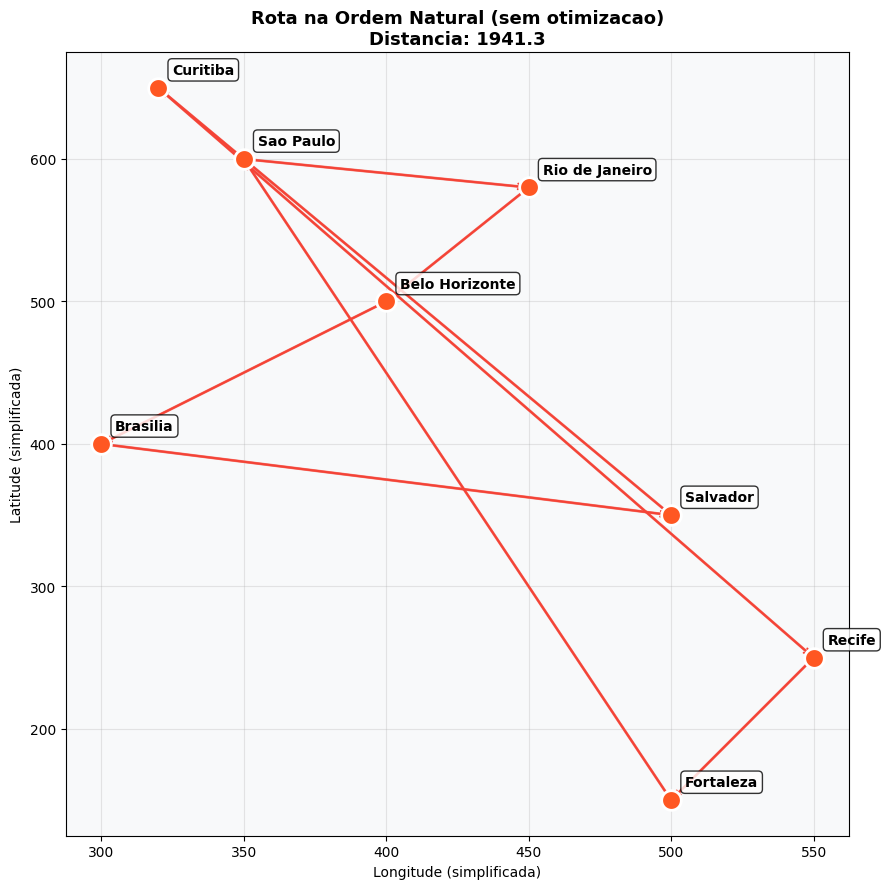

Observe o zigue-zague! O AG vai encontrar algo muito melhor.


In [6]:
# Visualizar a rota natural (sem otimizacao)
fig, ax = plt.subplots(figsize=(9, 9))
plotar_rota(rota_natural, 'Rota na Ordem Natural (sem otimizacao)', cor_linha='#F44336', ax=ax)
plt.tight_layout()
plt.show()

print("Observe o zigue-zague! O AG vai encontrar algo muito melhor.")

---
## Passo 4: Configurar o DEAP para TSP

| Aspecto | Mochila (Ex 06) | TSP (este) |
|:---|:---:|:---:|
| Cromossomo | Binario `[0,1,0,1]` | Permutacao `[3,1,0,2]` |
| Fitness | **Maximizar** valor | **Minimizar** distancia |
| Crossover | `cxOnePoint` | `cxOrdered` (ordenado) |
| Mutacao | `mutFlipBit` | `mutShuffleIndexes` (troca) |
| weights | `(1.0,)` | `(-1.0,)` |

In [7]:
# Fitness: MINIMIZAR (weights negativo!)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Gerar individuo: permutacao aleatoria de [0, 1, 2, ..., 7]
toolbox.register("indices", random.sample, range(NUM_CIDADES), NUM_CIDADES)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness
def funcao_fitness_tsp(individuo):
    return (distancia_total(individuo),)

toolbox.register("evaluate", funcao_fitness_tsp)

# OPERADORES ESPECIALIZADOS PARA PERMUTACAO:
toolbox.register("mate", tools.cxOrdered)              # Crossover Ordenado
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.1)  # Troca de posicoes
toolbox.register("select", tools.selTournament, tournsize=3)

print("DEAP configurado para TSP!")
print("  Crossover: cxOrdered (especializado para permutacao)")
print("  Mutacao: mutShuffleIndexes (troca cidades de posicao)")

DEAP configurado para TSP!
  Crossover: cxOrdered (especializado para permutacao)
  Mutacao: mutShuffleIndexes (troca cidades de posicao)


---
## Passo 5: Rodar o AG!

In [8]:
# Criar populacao
populacao = toolbox.population(n=100)

# Hall of Fame
hall_of_fame = tools.HallOfFame(1)

# Estatisticas
stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register("melhor", lambda x: round(min(x), 1))
stats.register("media", lambda x: round(sum(x) / len(x), 1))

# Rodar!
populacao_final, log = algorithms.eaSimple(
    populacao, toolbox,
    cxpb=0.8, mutpb=0.3, ngen=200,
    stats=stats, halloffame=hall_of_fame,
    verbose=True
)

gen	nevals	melhor	media 
0  	100   	1349.8	2030.1
1  	89    	1307.9	1901.1
2  	86    	1307.9	1820.6
3  	91    	1276.1	1811.4
4  	85    	1294.4	1740.6
5  	83    	1229.5	1656.7
6  	86    	1229.5	1609.6
7  	83    	1229.5	1614.6
8  	80    	1229.5	1608.1
9  	83    	1229.5	1506.1
10 	79    	1229.5	1530.3
11 	85    	1229.5	1500.2
12 	78    	1229.5	1464.5
13 	89    	1229.5	1414.8
14 	91    	1229.5	1407.5
15 	88    	1229.5	1445.5
16 	90    	1229.5	1474  
17 	81    	1229.5	1447.3
18 	86    	1229.5	1380.2
19 	91    	1229.5	1397  
20 	84    	1229.5	1355.1
21 	92    	1229.5	1376.3
22 	86    	1229.5	1292.1
23 	86    	1229.5	1313.7
24 	88    	1229.5	1328.2
25 	93    	1229.5	1287  
26 	88    	1229.5	1323.1
27 	86    	1229.5	1287.8
28 	92    	1229.5	1312.2
29 	82    	1229.5	1306.6
30 	85    	1229.5	1281.2
31 	81    	1229.5	1320.3
32 	95    	1229.5	1313.2
33 	89    	1229.5	1295.8
34 	98    	1229.5	1337.6
35 	79    	1229.5	1299.4
36 	83    	1229.5	1333.8
37 	81    	1229.5	1287.8
38 	84    	1229.5	1342.3


---
## Passo 6: Ver a melhor rota

In [9]:
melhor_rota = hall_of_fame[0]
melhor_distancia = distancia_total(melhor_rota)

print("MELHOR ROTA ENCONTRADA")
print("=" * 50)
print()
print("Percurso:")
for i, cidade_idx in enumerate(melhor_rota):
    nome = cidades[cidade_idx]["nome"]
    if i < len(melhor_rota) - 1:
        prox = melhor_rota[i + 1]
        dist = distancia(cidade_idx, prox)
        print("  ", i+1, ".", nome, " ->", round(dist, 1), "km")
    else:
        dist = distancia(cidade_idx, melhor_rota[0])
        print("  ", i+1, ".", nome, " ->", round(dist, 1), "km (volta)")
print("   ->", cidades[melhor_rota[0]]["nome"], "(retorno)")
print()
print("Distancia total:", round(melhor_distancia, 1))

MELHOR ROTA ENCONTRADA

Percurso:
   1 . Recife  -> 111.8 km
   2 . Fortaleza  -> 320.2 km
   3 . Brasilia  -> 250.8 km
   4 . Curitiba  -> 58.3 km
   5 . Sao Paulo  -> 102.0 km
   6 . Rio de Janeiro  -> 94.3 km
   7 . Belo Horizonte  -> 180.3 km
   8 . Salvador  -> 111.8 km (volta)
   -> Recife (retorno)

Distancia total: 1229.5


---
## Passo 7: Comparacao visual - Rota Natural vs Rota Otimizada

Agora o momento mais impactante: ver as duas rotas **lado a lado**!

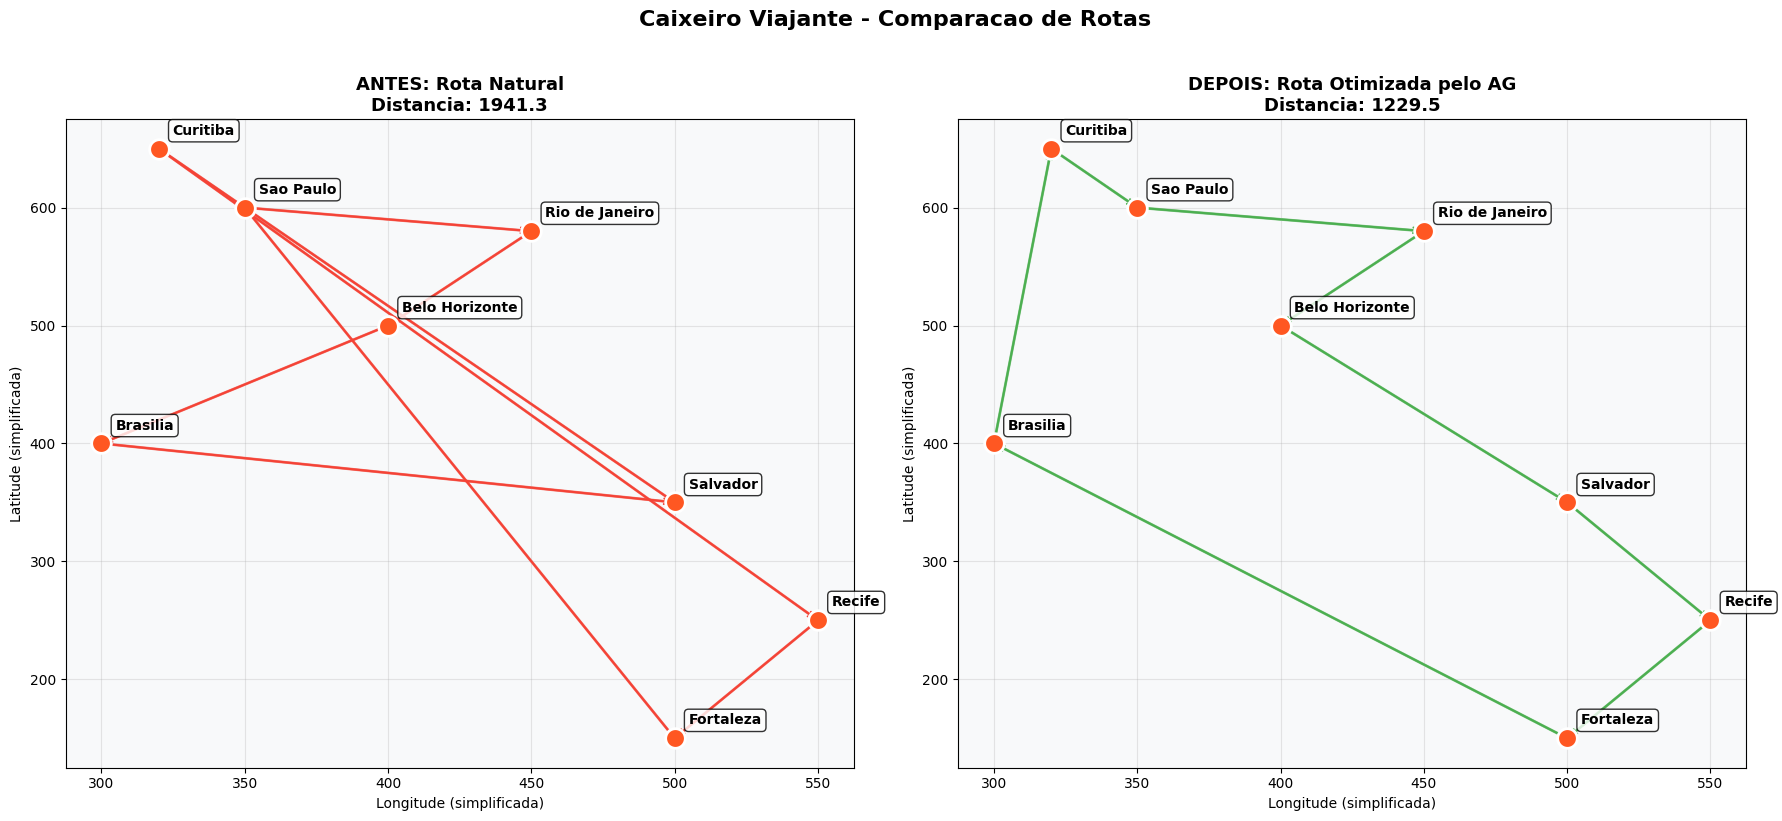

Rota natural: 1941.3
Rota otimizada: 1229.5
Economia: 36.7 %


In [10]:
# Grafico comparativo: lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Rota natural (nao otimizada)
plotar_rota(rota_natural, 'ANTES: Rota Natural', cor_linha='#F44336', ax=ax1)

# Rota otimizada pelo AG
plotar_rota(list(melhor_rota), 'DEPOIS: Rota Otimizada pelo AG', cor_linha='#4CAF50', ax=ax2)

plt.suptitle('Caixeiro Viajante - Comparacao de Rotas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mostrar economia
dist_natural = distancia_total(rota_natural)
economia = (1 - melhor_distancia / dist_natural) * 100
print("Rota natural:", round(dist_natural, 1))
print("Rota otimizada:", round(melhor_distancia, 1))
print("Economia:", round(economia, 1), "%")

---
## Passo 8: Grafico da evolucao do fitness

In [ ]:
# Extrair dados do log
geracoes = [entry['gen'] for entry in log]
melhores = [entry['melhor'] for entry in log]
medias = [entry['media'] for entry in log]

# Plotar
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(geracoes, melhores, color='#4CAF50', linewidth=2, label='Melhor')
ax.plot(geracoes, medias, color='#FF9800', linewidth=1, alpha=0.7, label='Media')
ax.set_xlabel('Geracao', fontsize=12)
ax.set_ylabel('Distancia', fontsize=12)
ax.set_title('Evolucao do Fitness ao Longo das Geracoes', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

print("Observe como a distancia diminui rapidamente nas primeiras geracoes")
print("e depois estabiliza (convergencia).")

---
## Passo 9: Validar com forca bruta

In [11]:
from itertools import permutations

melhor_bruta = None
melhor_dist_bruta = float("inf")

for perm in permutations(range(NUM_CIDADES)):
    dist = distancia_total(perm)
    if dist < melhor_dist_bruta:
        melhor_dist_bruta = dist
        melhor_bruta = perm

nomes_bruta = [cidades[i]["nome"] for i in melhor_bruta]
print("FORCA BRUTA")
print("Rota otima:", " -> ".join(nomes_bruta))
print("Distancia otima:", round(melhor_dist_bruta, 1))
print()

if round(melhor_distancia, 1) == round(melhor_dist_bruta, 1):
    print("O AG encontrou a rota OTIMA!")
else:
    pct = melhor_distancia / melhor_dist_bruta * 100
    print("O AG encontrou", round(pct, 1), "% da rota otima")

FORCA BRUTA
Rota otima: Recife -> Salvador -> Belo Horizonte -> Rio de Janeiro -> Sao Paulo -> Curitiba -> Brasilia -> Fortaleza
Distancia otima: 1229.5

O AG encontrou a rota OTIMA!


---
## Passo 10: Comparacao visual - AG vs Forca Bruta

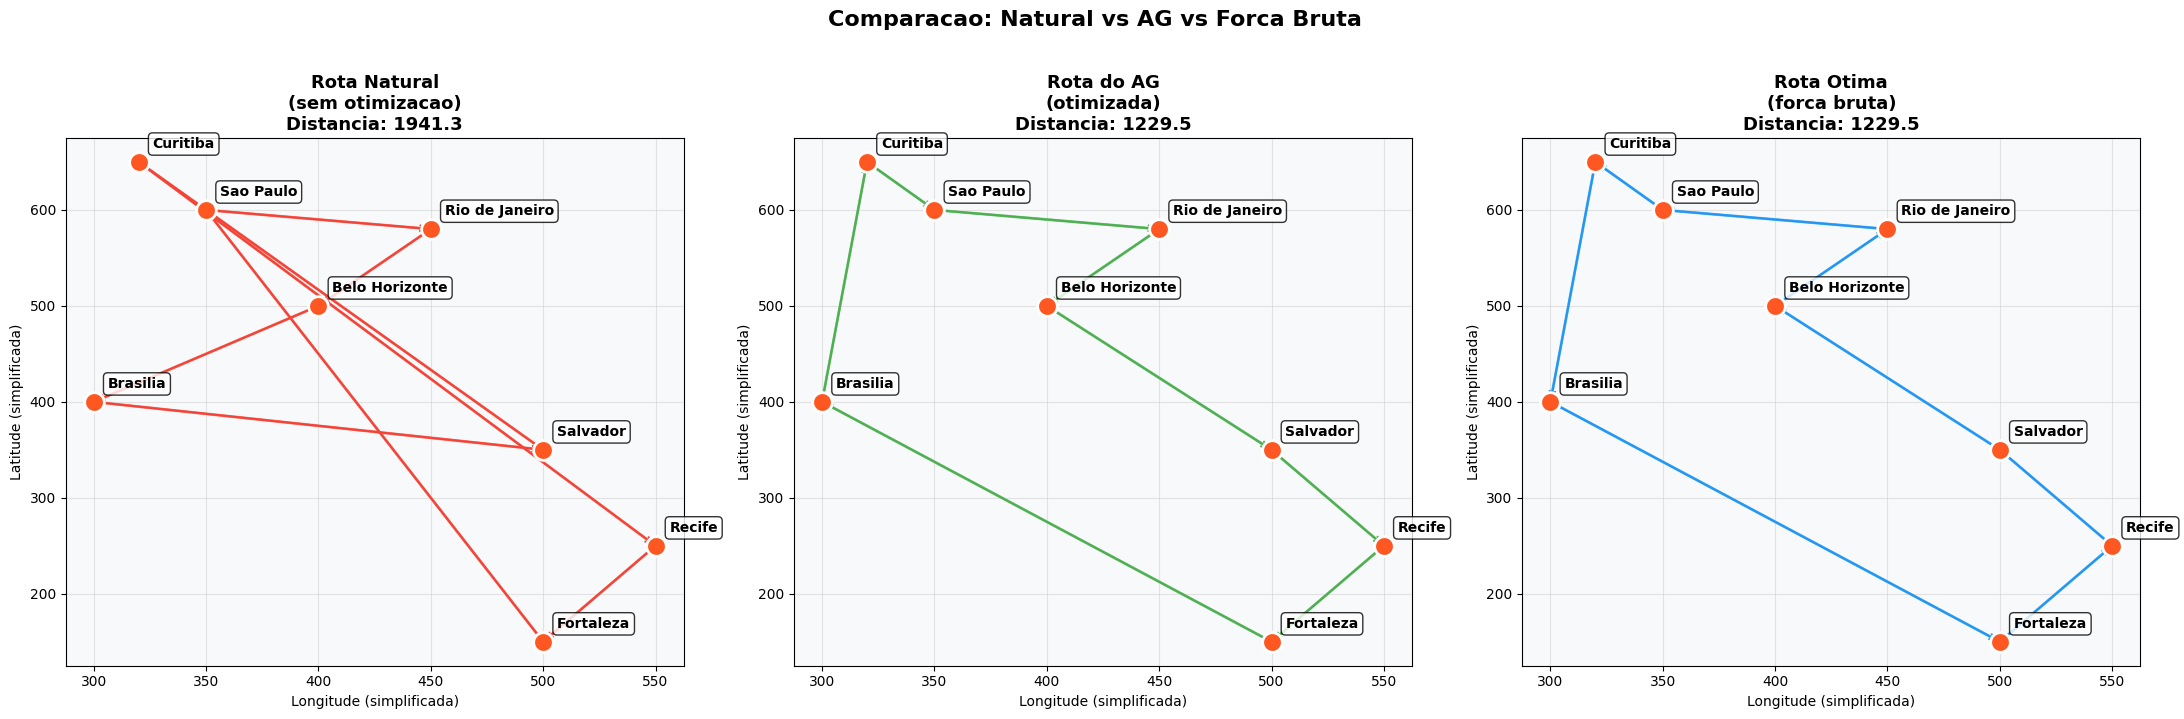

Com 8 cidades:  40320 rotas (viavel por forca bruta)
Com 20 cidades: 2432902008176640000 rotas (IMPOSSIVEL!)
O AG encontra boas solucoes rapidamente, mesmo para problemas enormes.


In [12]:
# 3 rotas lado a lado: natural, AG, forca bruta
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

plotar_rota(rota_natural, 'Rota Natural\n(sem otimizacao)', cor_linha='#F44336', ax=ax1)
plotar_rota(list(melhor_rota), 'Rota do AG\n(otimizada)', cor_linha='#4CAF50', ax=ax2)
plotar_rota(list(melhor_bruta), 'Rota Otima\n(forca bruta)', cor_linha='#2196F3', ax=ax3)

plt.suptitle('Comparacao: Natural vs AG vs Forca Bruta', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Com 8 cidades: ", math.factorial(8), "rotas (viavel por forca bruta)")
print("Com 20 cidades:", math.factorial(20), "rotas (IMPOSSIVEL!)")
print("O AG encontra boas solucoes rapidamente, mesmo para problemas enormes.")

---
## Resumo: Tipos de representacao em AGs

| Tipo | Cromossomo | Exemplo | Operadores |
|:---|:---|:---|:---|
| **Binaria** | `[0, 1, 0, 1]` | Mochila (Ex 02) | cxOnePoint, mutFlipBit |
| **Permutacao** | `[3, 1, 0, 2]` | TSP (este) | cxOrdered, mutShuffleIndexes |
| Real | `[0.5, 1.2, 3.7]` | Otimizacao de funcoes | cxBlend, mutGaussian |

### Licao principal:

> **A escolha da representacao determina quais operadores podemos usar!**  
> Usar crossover de 1 ponto em permutacoes QUEBRA a solucao. Sempre escolha operadores compativeis com a representacao.

### Exercicio:

Adicione mais 2 cidades (ex: Manaus (100, 200) e Porto Alegre (310, 750)) e rode novamente. O AG ainda encontra uma boa solucao?